# Model Dataset v1.0 — Exploratory Data Analysis

**Gate before training.** This notebook answers *"what does the data look like?"* —
it does NOT train anything. The separate `model_datasets/validate_dataset.py` answers
*"is the dataset safe?"* (run it first; it writes `validation_report.json`).

- Grain: one Gold-B inspection interval per row; labels describe the **next** interval.
- Provenance: `model_datasets/v1.0/model_dataset_manifest_v1.0.json`.
- Split: grouped temporal (by wheelset median interval-end), 70/15/15 train/val/test.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
%matplotlib inline

# Run from project root or from notebooks/
cwd = Path.cwd()
DATA = (cwd / "model_datasets" / "v1.0") if (cwd / "model_datasets" / "v1.0").exists() else (cwd.parent / "model_datasets" / "v1.0")
if not (DATA / "model_dataset_v1.0.parquet").exists():
    raise FileNotFoundError("model dataset not found; run from project root or notebooks/")

df = pd.read_parquet(DATA / "model_dataset_v1.0.parquet")
manifest = json.loads((DATA / "model_dataset_manifest_v1.0.json").read_text(encoding="utf-8"))
roles = manifest["column_roles"]
x_cols = [c for c, r in roles.items() if r == "feature"]
y_cols = [c for c, r in roles.items() if r == "label"]

print("dataset_version:", manifest["dataset_version"],
      "| feature_store:", manifest["feature_store_version"],
      "| feature_spec:", manifest["feature_spec_version"],
      "| label_spec:", manifest["label_spec_version"])
print("rows:", df.shape[0], "| features:", len(x_cols), "| labels:", len(y_cols))
print("fingerprint:", manifest["fingerprint"])

dataset_version: v1.0 | feature_store: 1.0.0 | feature_spec: 1.0.0 | label_spec: 1.0.0
rows: 202237 | features: 58 | labels: 6
fingerprint: c01d6e55e800e0b5


## 1. Overview

In [2]:
print("Wheelsets:", df['wheelset_equipment_id'].nunique(),
      "| Locos:", df['locomotive_id'].nunique())
print("Date range:", df['interval_end_timestamp'].min(), "->", df['interval_end_timestamp'].max())
print("\nSplit sizes:")
print(df['split'].value_counts().sort_index().to_string())
print("\nSplit date ranges (grouped temporal overlap is expected):")
print(df.groupby('split')['interval_end_timestamp'].agg(['min', 'max']).to_string())

Wheelsets: 15409 | Locos: 2072
Date range: 2015-01-18 00:00:00 -> 2026-07-22 00:00:00

Split sizes:
split
test      28066
train    144428
val       29743

Split date ranges (grouped temporal overlap is expected):
             min        max
split                      
test  2019-06-25 2026-07-22
train 2015-01-18 2026-07-22
val   2015-06-01 2026-07-20


## 2. Target distributions

### 2a. Regression — next-interval diameter change (`next_interval_dia_delta_mm`)
> Warning: label contains sentinel outliers from un-quarantined source measurements
> (min/max ~ +/-1090 mm). A quarantined label version is planned (label_spec >= 1.1).

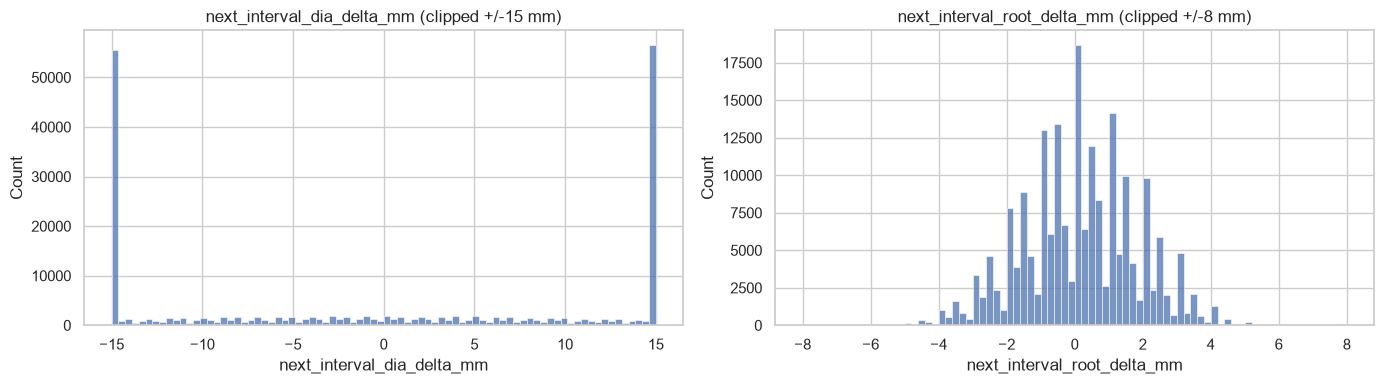

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['next_interval_dia_delta_mm'].clip(-15, 15), bins=80, ax=axes[0])
axes[0].set_title("next_interval_dia_delta_mm (clipped +/-15 mm)")
sns.histplot(df['next_interval_root_delta_mm'].clip(-8, 8), bins=80, ax=axes[1])
axes[1].set_title("next_interval_root_delta_mm (clipped +/-8 mm)")
plt.tight_layout(); plt.show()

### 2b. Binary targets — prevalence (imbalance check)

                               positive_rate
next_interval_turning_flag          0.011309
next_interval_large_loss_flag       0.616005


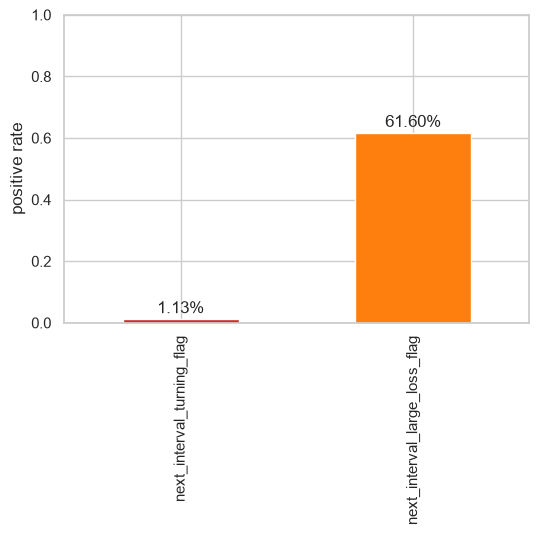

In [4]:
prev = pd.DataFrame({
    'next_interval_turning_flag': df['next_interval_turning_flag'].mean(),
    'next_interval_large_loss_flag': df['next_interval_large_loss_flag'].mean(),
}, index=['positive_rate']).T
print(prev.to_string())
fig, ax = plt.subplots(figsize=(6, 4))
prev['positive_rate'].plot(kind='bar', ax=ax, color=['#d62728', '#ff7f0e'])
ax.set_ylabel("positive rate"); ax.set_ylim(0, 1)
for i, v in enumerate(prev['positive_rate']):
    ax.text(i, v + 0.02, f"{v:.2%}", ha='center')
plt.show()

### 2c. Survival — days to next turning (heavy right-censoring)

censored rate: 91.35%


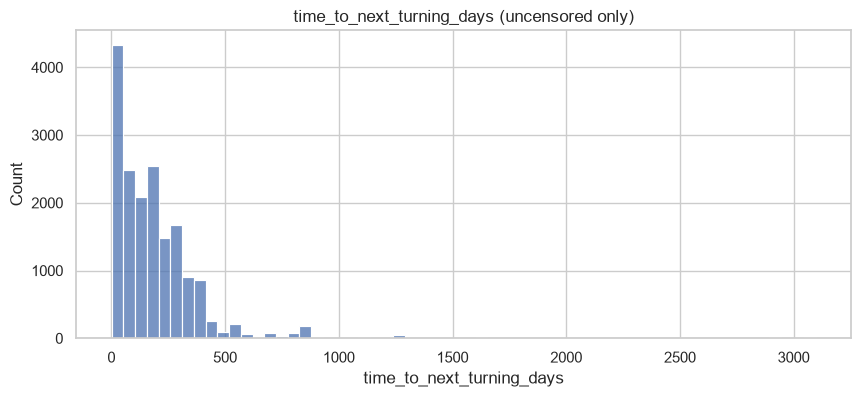

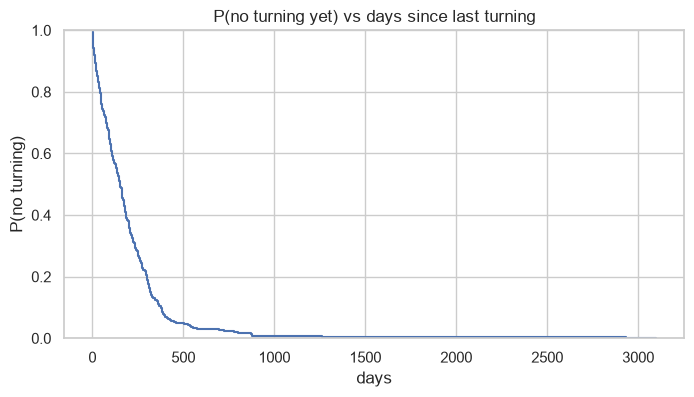

In [5]:
uncensored = df[~df['censored_flag']]
print(f"censored rate: {df['censored_flag'].mean():.2%}")
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(uncensored['time_to_next_turning_days'].dropna(), bins=60, ax=ax)
ax.set_title("time_to_next_turning_days (uncensored only)")
plt.show()

# K-M-style survival curve on the uncensored horizon
from scipy.stats import ecdf  # noqa: E402
if len(uncensored):
    e = ecdf(uncensored['time_to_next_turning_days'])
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.step(e.cdf.quantiles, 1 - e.cdf.probabilities, where='post')
    ax.set_title("P(no turning yet) vs days since last turning"); ax.set_ylim(0, 1)
    ax.set_xlabel("days"); ax.set_ylabel("P(no turning)")
    plt.show()

## 3. Feature distributions (a representative sample of numeric X)

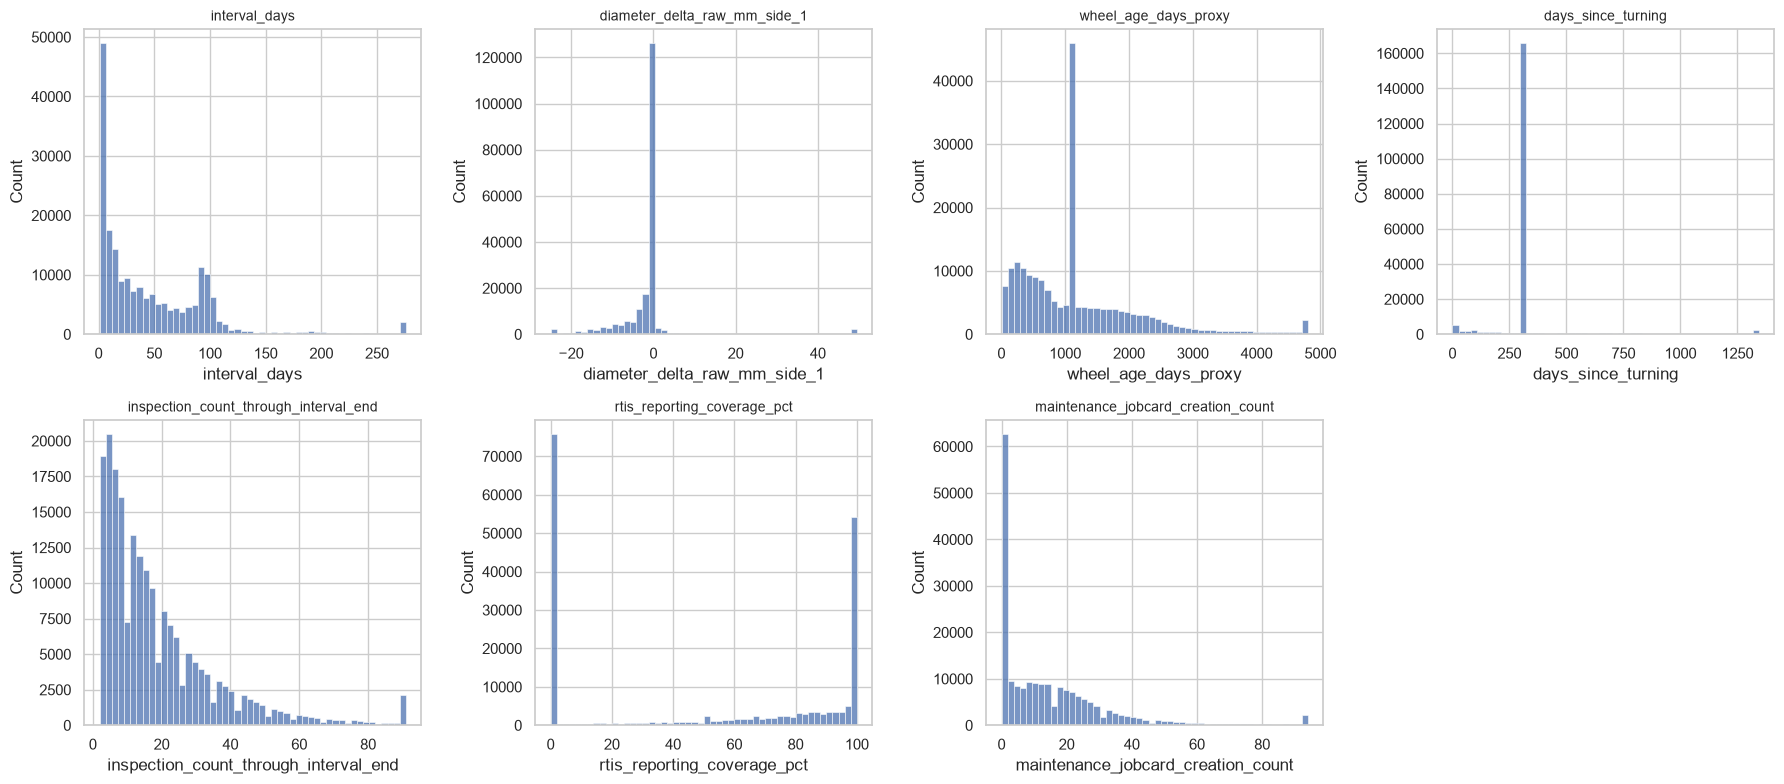

In [6]:
num = [c for c in x_cols if df[c].dtype.kind in "fiu" and "__" not in c]
pick = ["interval_days", "diameter_delta_raw_mm_side_1", "wheel_age_days_proxy",
        "days_since_turning", "inspection_count_through_interval_end",
        "rtis_reporting_coverage_pct", "maintenance_jobcard_creation_count"]
pick = [c for c in pick if c in num]
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), pick + [None] * (8 - len(pick))):
    if col is None:
        ax.set_visible(False); continue
    sns.histplot(df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99)), bins=50, ax=ax)
    ax.set_title(col, fontsize=10)
plt.tight_layout(); plt.show()

## 4. Missingness

X is fully populated by construction (NA sentinels are encoded). Labels carry the
real missingness — mainly right-censoring of the survival label.

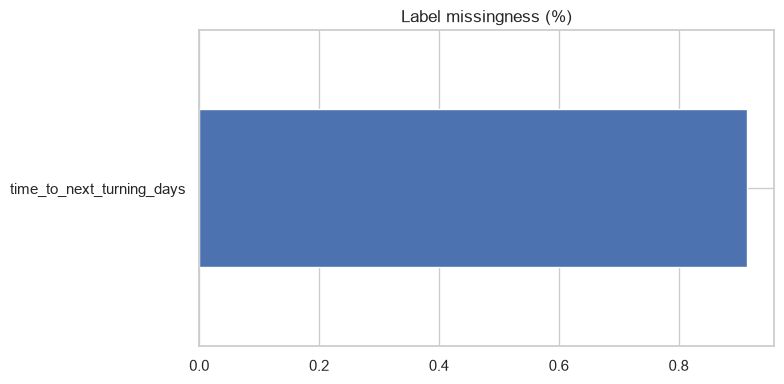

X NA cells: 0


In [7]:
na = pd.Series({c: df[c].isna().mean() for c in y_cols})
fig, ax = plt.subplots(figsize=(8, 4))
na[na > 0].sort_values().plot(kind='barh', ax=ax)
ax.set_title("Label missingness (%)")
plt.tight_layout(); plt.show()
print("X NA cells:", int(df[x_cols].isna().sum().sum()))

## 5. Group & time coverage

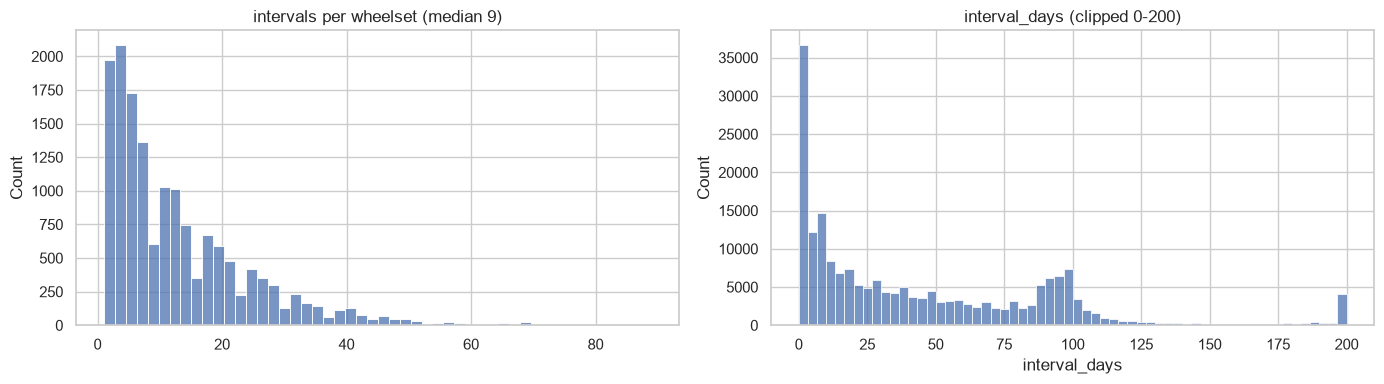

In [8]:
counts = df.groupby('wheelset_equipment_id').size()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(counts, bins=50, ax=axes[0])
axes[0].set_title(f"intervals per wheelset (median {counts.median():.0f})")
sns.histplot(df['interval_days'].clip(0, 200), bins=60, ax=axes[1])
axes[1].set_title("interval_days (clipped 0-200)")
plt.tight_layout(); plt.show()

## 6. Correlations

Feature-label (linear) and top feature-feature pairs. These are reported for
context; collinearity is expected (e.g. wheel position vs axle position, RTIS
count vs reporting days).

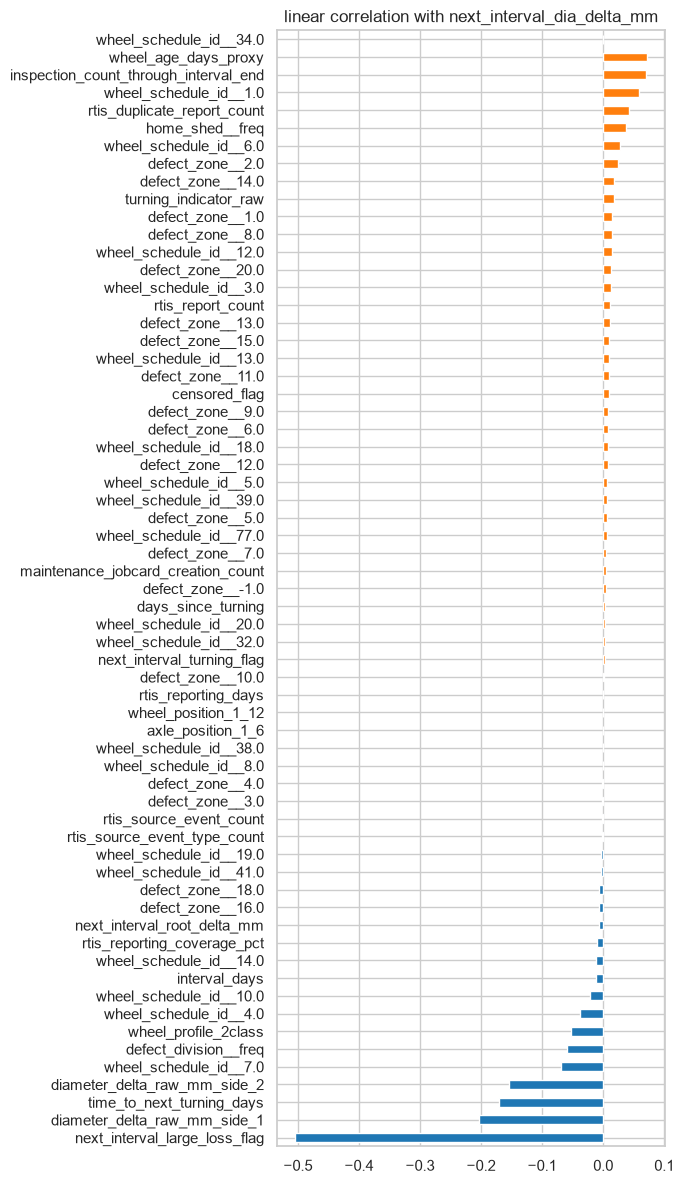

                            feature_a                    feature_b  |corr|
                  wheel_position_1_12            axle_position_1_6   1.000
                  rtis_reporting_days            rtis_report_count   0.959
              rtis_source_event_count rtis_source_event_type_count   0.921
         diameter_delta_raw_mm_side_2 diameter_delta_raw_mm_side_1   0.839
                        interval_days          rtis_reporting_days   0.664
                    rtis_report_count                interval_days   0.643
                      home_shed__freq         wheel_profile_2class   0.578
inspection_count_through_interval_end         wheel_age_days_proxy   0.550
   maintenance_jobcard_creation_count                interval_days   0.543
                 wheel_profile_2class        defect_division__freq   0.528


In [9]:
sub = df.sample(min(len(df), 60000), random_state=42)
corr = sub[x_cols + y_cols].corr(numeric_only=True)
lab = corr['next_interval_dia_delta_mm'].drop('next_interval_dia_delta_mm')
lab = lab.sort_values()
fig, ax = plt.subplots(figsize=(7, 12))
lab.plot(kind='barh', ax=ax, color=np.where(lab.values < 0, '#1f77b4', '#ff7f0e'))
ax.set_title("linear correlation with next_interval_dia_delta_mm")
plt.tight_layout(); plt.show()

# top feature-feature pairs
mask = ~np.eye(len(corr), dtype=bool)
ff = corr.where(mask).abs().unstack().dropna().sort_values(ascending=False)
seen, top = set(), []
for (a, b), v in ff.items():
    key = tuple(sorted((str(a), str(b))))
    if key in seen or (a == b):
        continue
    seen.add(key); top.append((a, b, round(v, 3)))
    if len(top) >= 10:
        break
print(pd.DataFrame(top, columns=['feature_a', 'feature_b', '|corr|']).to_string(index=False))

## 7. Split sanity — label prevalence must be comparable across splits

       turning_rate  large_loss_rate  dia_delta_mean  censored_rate
split                                                              
test         0.0111           0.7154         -7.3869         0.9177
train         0.011           0.5935          2.9123         0.9190
val          0.0132           0.6314         -3.1895         0.8827


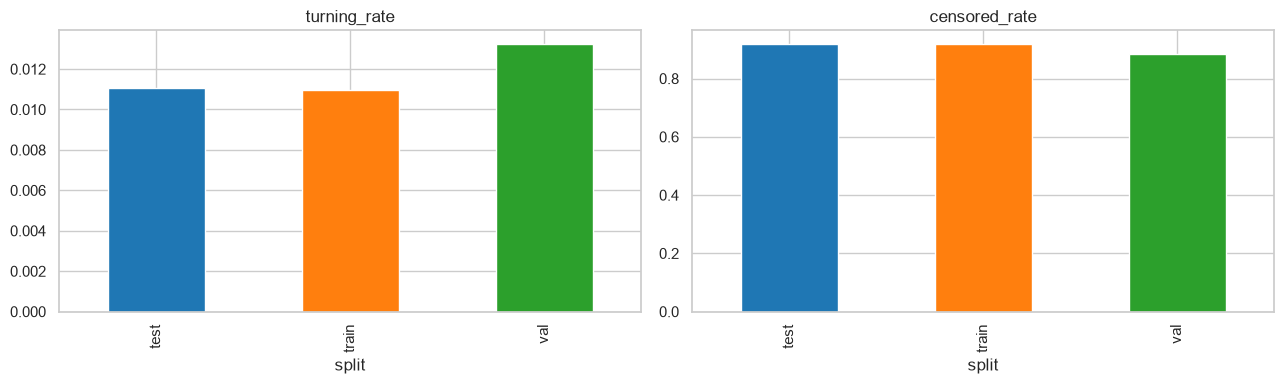

In [10]:
comp = df.groupby('split').agg(
    turning_rate=('next_interval_turning_flag', 'mean'),
    large_loss_rate=('next_interval_large_loss_flag', 'mean'),
    dia_delta_mean=('next_interval_dia_delta_mm', 'mean'),
    censored_rate=('censored_flag', 'mean'),
)
print(comp.round(4).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ['turning_rate', 'censored_rate']):
    comp[col].plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_title(col)
plt.tight_layout(); plt.show()

## 8. Take-aways to carry into model selection

1. **Regression target is noisy** (large std, sentinel outliers) — expect weak absolute
   RMSE; judge models vs the median/mean dummy, not vs 0.
2. **Turning is rare (~1.1%)** — use PR-AUC / precision@k, not accuracy.
3. **Survival label is 91% right-censored** — survival methods (C-index), not plain RMSE.
4. **Top signal so far:** current-interval diameter delta, wheel age, inspection count,
   schedule id — all point-in-time safe.
5. **Collinear blocks:** wheel_position vs axle_position; RTIS count/days. Fine for
   trees; keep in mind for linear models.